# Cell segmentation & clustering


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import spatiomic as so

## Data loading


In [2]:
img_data = so.data.read().read_tiff("./data/nuclei_mouse.tiff", input_dimension_order="CYX")
img_data.shape

(1024, 1024, 1)

## Cellpose segmentation


In [3]:
masks, flows, styles = so.segment.cellpose().predict(img_data)



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	darwin 
python version: 	3.12.10 
torch version:  	2.8.0! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




We can extend the masks, e.g., to also include the cytoplasm.


In [4]:
extended_masks = so.segment.extend_mask(masks, dilation_pixels=20)

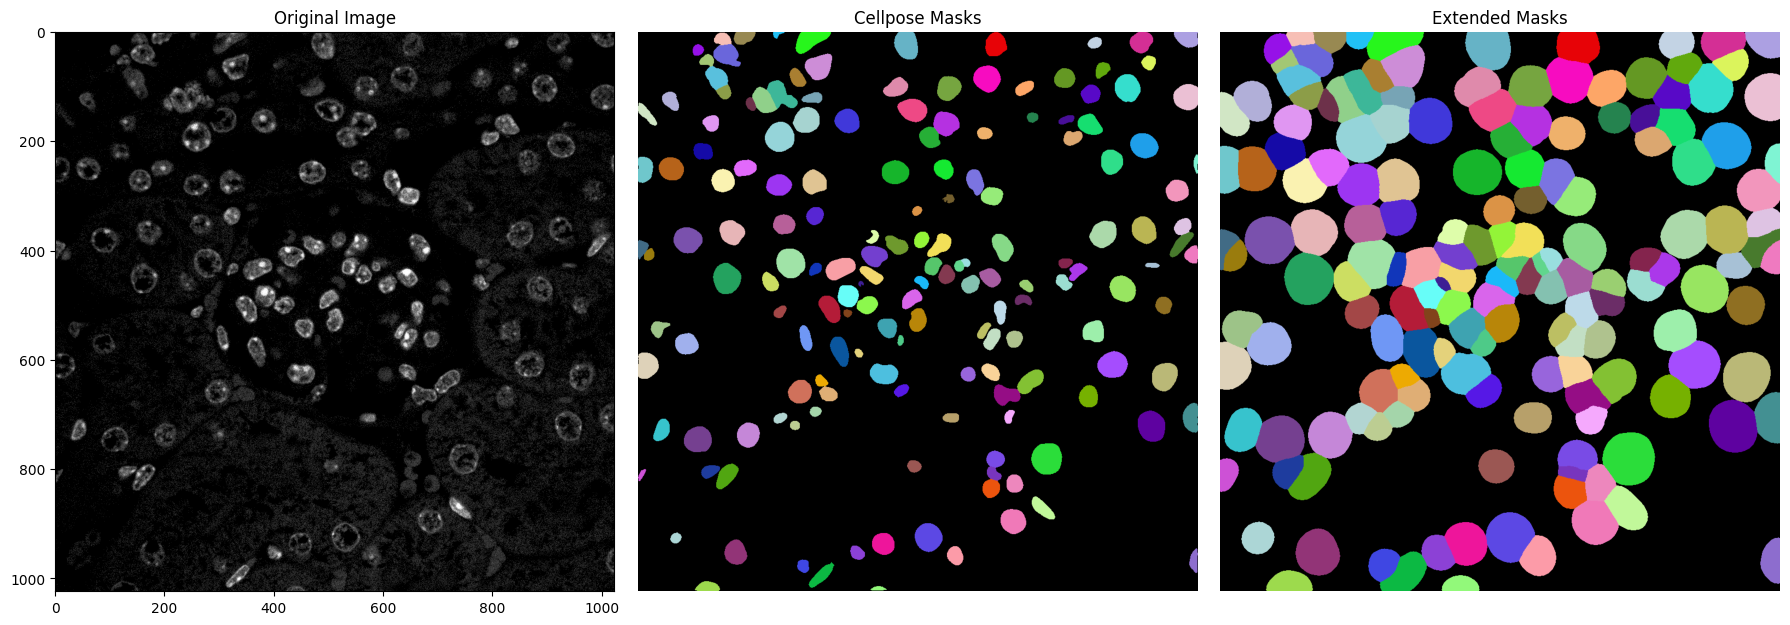

In [5]:
fig, (axes) = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_data[..., 0], cmap="gray")
axes[0].set_title("Original Image")
so.plot.cluster_image(masks, ax=axes[1], show_colorbar=False, title="Cellpose Masks")
so.plot.cluster_image(extended_masks, ax=axes[2], show_colorbar=False, title="Extended Masks")
plt.tight_layout()
plt.show()

## Cluster the image

We will now cluster the original DAPI image to generate pixel clusters that we can quantify at the cell level. Normally, you would follow the clustering tutorial and use the multi-channel image as input. Here, we only need some data at the pixel level to show how we can aggregate it at the cluster level.


In [6]:
som = so.dimension.som(
    node_count=(10, 10),
    dimension_count=img_data.shape[-1],
    distance_metric="euclidean",
    use_gpu=False,
    seed=42,
)
som.fit(img_data.reshape(-1, img_data.shape[-1]), iteration_count=10)

In [7]:
knn_graph = so.neighbor.knn_graph().create(
    som,
    neighbor_count=10,
)
communities, modularity = so.cluster.leiden().predict(knn_graph, resolution=1.0)
labelled_image = som.label(img_data, communities)

/Users/au734063/Documents/spatiomic/spatiomic/neighbor/_knn_graph.py:66: UserWarning: Could not import cuml implementation. Switching to non-GPU implementation.
  neighbor_finder = get_neighbor_finder(


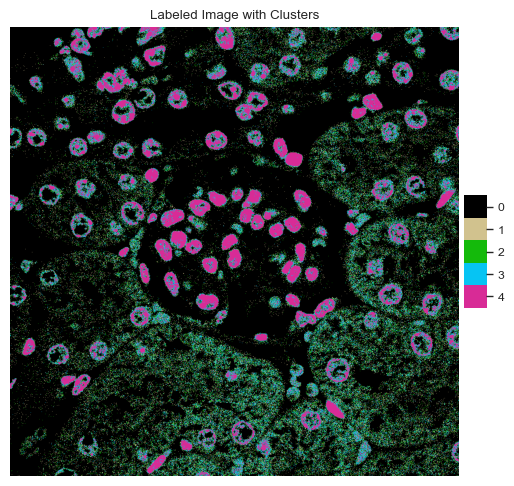

In [8]:
fig = so.plot.cluster_image(labelled_image, title="Labeled Image with Clusters")

## Quantify pixel-level features at the cell-level


In [9]:
cluster_counts = so.segment.count_clusters(
    labelled_image, extended_masks, cluster_count=np.max(communities) + 1, normalize=True
)
cluster_counts.head(5)

,0,1,2,3,4
mask_region,,,,,
1,0.587961,0.023871,0.042553,0.119357,0.226258
2,0.594459,0.037995,0.051451,0.115040,0.201055
3,0.564260,0.047005,0.063467,0.091035,0.234232
4,0.731239,0.043630,0.072717,0.102676,0.049738
5,0.670197,0.027988,0.044251,0.116490,0.141074


## Cluster cells


In [10]:
knn_graph_counts = so.neighbor.knn_graph().create(
    cluster_counts.values,
    neighbor_count=10,
    distance_metric="cosine",
)
communities_counts, modularity_counts = so.cluster.leiden().predict(knn_graph_counts, resolution=1.0)

/Users/au734063/Documents/spatiomic/spatiomic/neighbor/_knn_graph.py:66: UserWarning: Could not import cuml implementation. Switching to non-GPU implementation.
  neighbor_finder = get_neighbor_finder(


In [11]:
clustered_cells = so.segment.assign_communities(extended_masks, communities_counts)

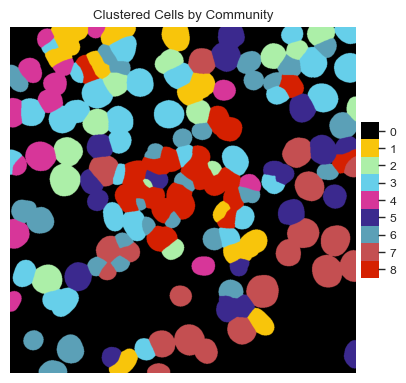

In [12]:
fig = so.plot.cluster_image(clustered_cells, title="Clustered Cells by Community", figsize=(4, 4))

## Plot the results


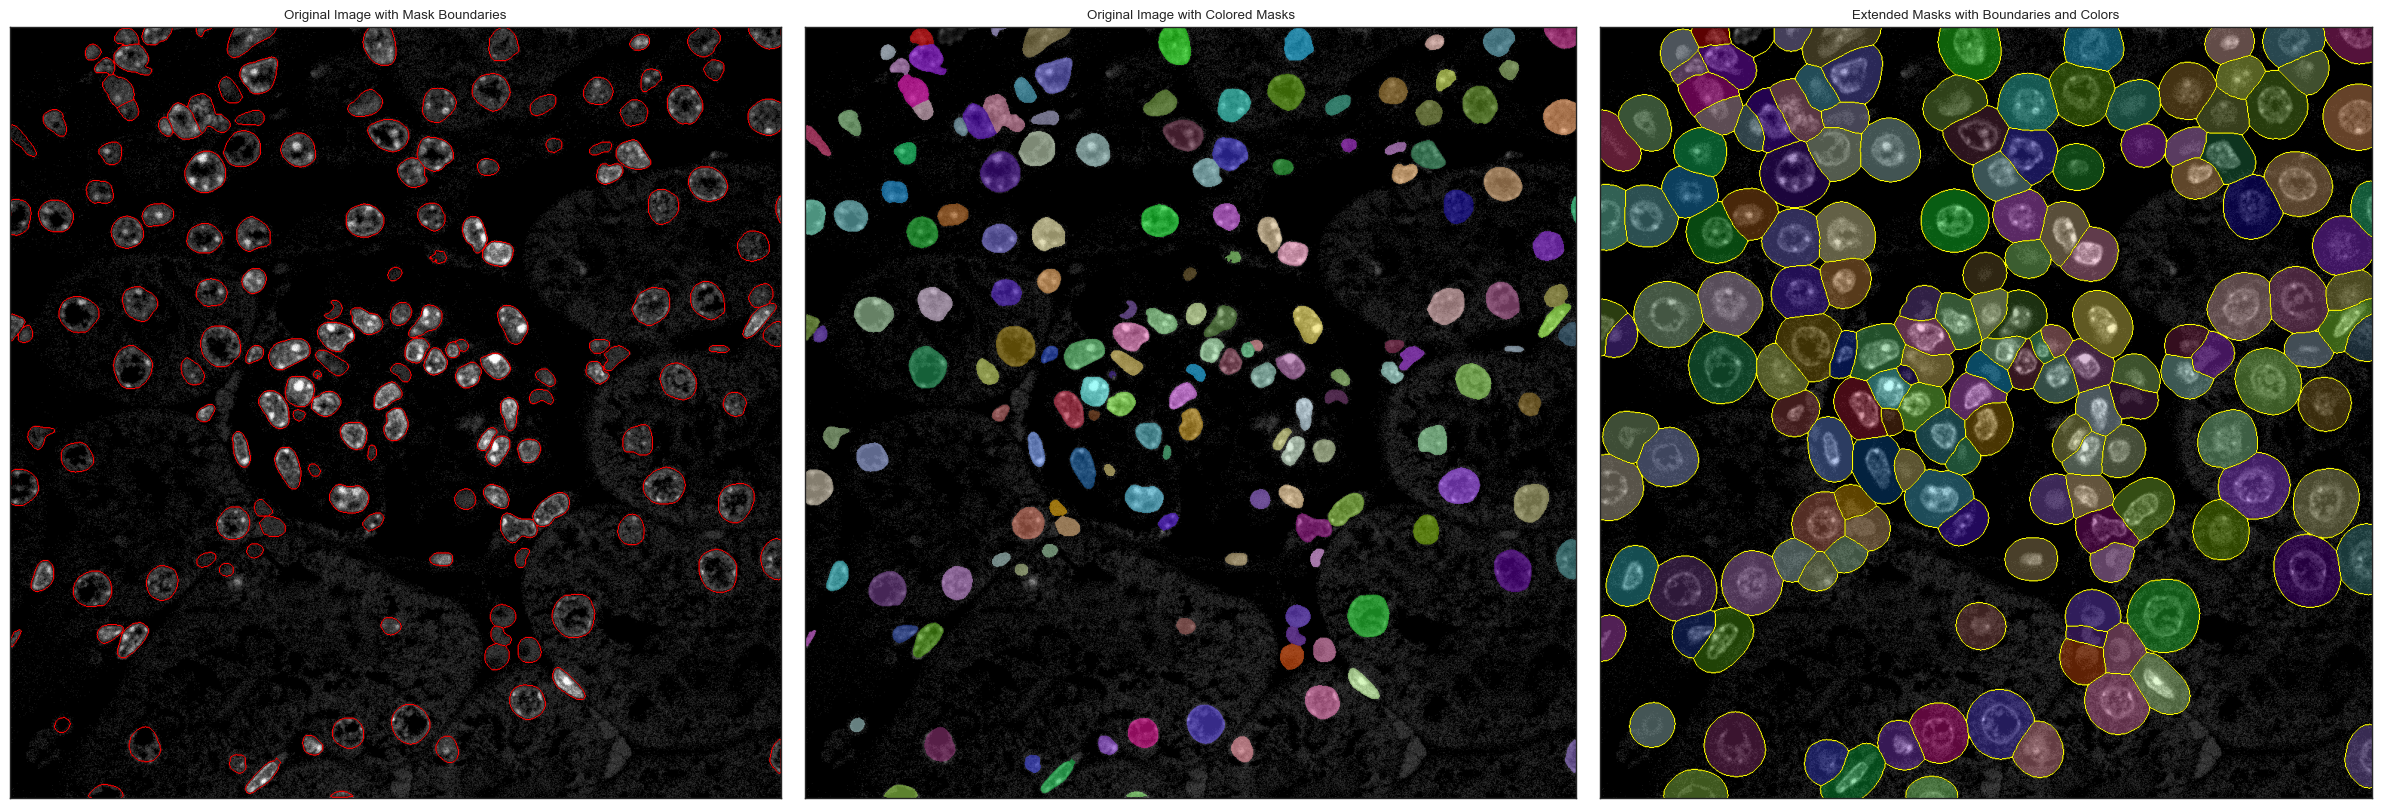

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

ax1 = so.plot.segmentation_overlay(
    img_data[..., 0],
    masks,
    boundary_color="#FF0000",
    show_boundaries=True,
    show_masks=False,
    ax=ax1,
    figsize=(8, 6),
)
ax1.set_title("Original Image with Mask Boundaries")

ax2 = so.plot.segmentation_overlay(
    img_data[..., 0],
    masks,
    show_boundaries=False,
    show_masks=True,
    mask_alpha=0.6,
    ax=ax2,
    figsize=(8, 6),
)
ax2.set_title("Original Image with Colored Masks")

ax3 = so.plot.segmentation_overlay(
    img_data[..., 0],
    extended_masks,
    boundary_color="#FFFF00",
    show_boundaries=True,
    show_masks=True,
    mask_alpha=0.4,
    ax=ax3,
    figsize=(8, 6),
)
ax3.set_title("Extended Masks with Boundaries and Colors")

plt.tight_layout()

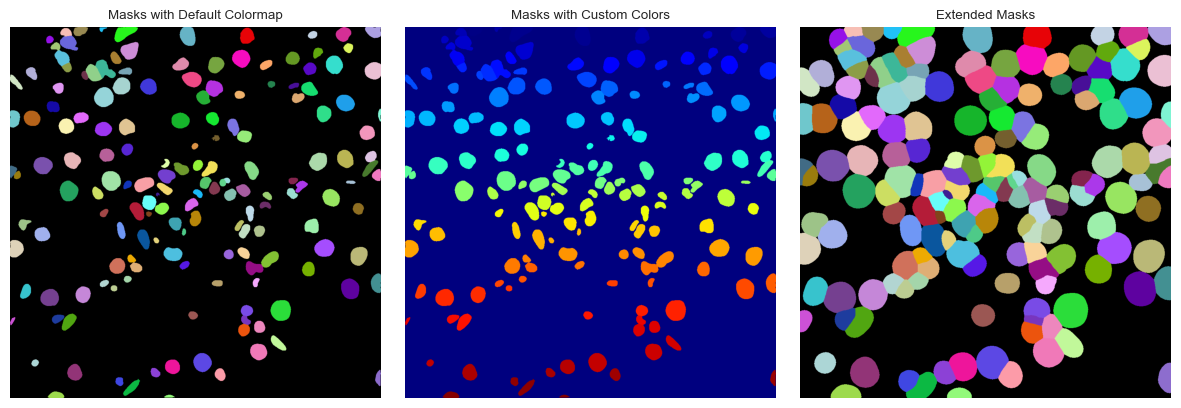

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

ax1 = so.plot.cluster_image(masks, title="Masks with Default Colormap", show_colorbar=False, ax=axes[0])
ax2 = so.plot.cluster_image(masks, colormap="jet", show_colorbar=False, title="Masks with Custom Colors", ax=axes[1])
ax3 = so.plot.cluster_image(extended_masks, ax=axes[2], show_colorbar=False, title="Extended Masks")

plt.tight_layout()